In [ ]:
# Preparing pathing
from titanic_ml import paths


ImportError: cannot import name 'Path' from 'titanic_ml' (C:\Users\jonma\Documents\GitHub\Machine_learning\Titanic\titanic_ml\__init__.py)

In [2]:
from titanic_ml.data import load_train_data

df = load_train_data()
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
# EDA: Exploratory Data Analysis

TARGET = 'Survived'

print('DataFrame info:')
df.info()
print('------------------------')
print()
print('Describe numeric features:')
print(df.describe(include=['int64', 'float64']))
print('------------------------')
print()
print('Describe categorical features:')
print(df.describe(include=['object']))
print('------------------------')
print()
print('DataFrame head:')
print(df.head())
print('------------------------')
print()
print('Missing values:')
print(df.isnull().sum())
print('------------------------')

DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
------------------------

Describe numeric features:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2

In [12]:
from titanic_ml.common.data.eda import quick_description

quick_description(df)

DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
------------------------
DataFrame shape: (891, 12)
------------------------
DataFrame columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']
---------------

In [23]:
print('DataFrame columns:', df.columns.tolist())
# Deep description

categorical_cols = df.select_dtypes(include=['object', 'category'])
columns = categorical_cols.columns.tolist()
for col in columns:
    print(f'Column: {col}')
    print(df[col].value_counts())
    print('------------------------')

numeric_cols = df.select_dtypes(include=['int64', 'float64'])
# columns = numeric_cols.columns.tolist()
for col in columns:
    print(f'Column: {col}')
    print(df[col].describe())
    print('------------------------')

DataFrame columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']
Column: Name
Name
Braund, Mr. Owen Harris                     1
Boulos, Mr. Hanna                           1
Frolicher-Stehli, Mr. Maxmillian            1
Gilinski, Mr. Eliezer                       1
Murdlin, Mr. Joseph                         1
                                           ..
Kelly, Miss. Anna Katherine "Annie Kate"    1
McCoy, Mr. Bernard                          1
Johnson, Mr. William Cahoone Jr             1
Keane, Miss. Nora A                         1
Dooley, Mr. Patrick                         1
Name: count, Length: 891, dtype: int64
------------------------
Column: Sex
Sex
male      577
female    314
Name: count, dtype: int64
------------------------
Column: Ticket
Ticket
347082      7
CA. 2343    7
1601        7
3101295     6
CA 2144     6
           ..
9234        1
19988       1
2693        1
PC 17612    1
370376      1
Name:

In [20]:
import pandas as pd

def summarize_column(series, max_display=20):
    # Count frequencies including NaN
    counts = series.value_counts(dropna=False)

    # Percentages
    percents = (
        series.value_counts(dropna=False, normalize=True) * 100
    ).round(2)

    # Build summary table
    summary = pd.DataFrame({
        'count': counts,
        'percent': percents
    })

    # Renaming NA/None to 'MISSING' for better readability
    summary = summary.rename(index={pd.NA: 'MISSING', None: 'MISSING'})

    # If small enough, show everything
    if len(summary) <= max_display:
        return summary

    # Otherwise show top/bottom
    top_n = max_display // 2

    truncated = pd.concat([
        summary.head(top_n),
        pd.DataFrame(
            {'count': ['...'], 'percent': ['...']},
            index=['...']
        ),
        summary.tail(top_n)
    ])

    return truncated

In [21]:
summarize_column(df['Cabin'])

,count,percent
NaN,687,77.1
C23 C25 C27,4,0.45
G6,4,0.45
B96 B98,4,0.45
C22 C26,3,0.34
D,3,0.34
F33,3,0.34
E101,3,0.34
F2,3,0.34
B20,2,0.22


In [22]:
for col in df.select_dtypes(include=['object', 'category']):
    print(f'\n=== {col} ===')
    print(summarize_column(df[col]))


=== Name ===
                                                count percent
Braund, Mr. Owen Harris                             1    0.11
Boulos, Mr. Hanna                                   1    0.11
Frolicher-Stehli, Mr. Maxmillian                    1    0.11
Gilinski, Mr. Eliezer                               1    0.11
Murdlin, Mr. Joseph                                 1    0.11
Rintamaki, Mr. Matti                                1    0.11
Stephenson, Mrs. Walter Bertram (Martha Eustis)     1    0.11
Elsbury, Mr. William James                          1    0.11
Bourke, Miss. Mary                                  1    0.11
Chapman, Mr. John Henry                             1    0.11
...                                               ...     ...
Lewy, Mr. Ervin G                                   1    0.11
Hanna, Mr. Mansour                                  1    0.11
Allison, Miss. Helen Loraine                        1    0.11
Saalfeld, Mr. Adolphe                               1   

In [28]:
for col in df.columns:
    s = df[col]

    print(f"\n{'='*60}")
    print(f"{col}")
    print(f"{'-'*60}")
    print(f"dtype       : {s.dtype}")
    print(f"rows        : {len(s)}")
    print(f"missing     : {s.isna().sum()} ({s.isna().mean()*100:.2f}%)")
    print(f"unique      : {s.nunique(dropna=True)}")

    if s.dtype == 'object' or str(s.dtype) == 'category':
        print(summarize_column(s))


PassengerId
------------------------------------------------------------
dtype       : int64
rows        : 891
missing     : 0 (0.00%)
unique      : 891

Survived
------------------------------------------------------------
dtype       : int64
rows        : 891
missing     : 0 (0.00%)
unique      : 2

Pclass
------------------------------------------------------------
dtype       : int64
rows        : 891
missing     : 0 (0.00%)
unique      : 3

Name
------------------------------------------------------------
dtype       : object
rows        : 891
missing     : 0 (0.00%)
unique      : 891
                                                count percent
Braund, Mr. Owen Harris                             1    0.11
Boulos, Mr. Hanna                                   1    0.11
Frolicher-Stehli, Mr. Maxmillian                    1    0.11
Gilinski, Mr. Eliezer                               1    0.11
Murdlin, Mr. Joseph                                 1    0.11
Rintamaki, Mr. Matti          

In [39]:
# Length of string columns
length = df['Embarked'].str.len().describe()
print(f"Length of 'Embarked':\n{length}")

'''
This reveals:

free text
codes
IDs
malformed entries

Example:

all length 2 → state codes
all length 36 → UUIDs
huge variance → real text

Very powerful for schema discovery.
'''


# Cardinality: number of unique values / total rows
cardinality = df['Embarked'].nunique(dropna=True) / len(df['Embarked'])
print(f"Cardinality of 'Embarked': {cardinality:.2%}")

# Ratio	Meaning
'''
Very low = categorical
Medium = mixed
Very high = ID-like/free text

Example:

gender → 0.00002
country → 0.01
customer_id → 1.0

This immediately reveals:

IDs
UUIDs
text fields
columns unsuitable for one-hot encoding
'''

# Dominance Ratio
top_freq = df['Embarked'].value_counts(dropna=False, normalize=True).iloc[0]
print(f"Dominance Ratio of 'Embarked': {top_freq:.2%}")

'''
Dominance Ratio	Meaning
Very low = no dominant category
Medium = some dominance
Very high = one category dominates

useful for detecting useless columns.

If:

one value = 99%
column may be useless

Example:
"ACTIVE" repeated everywhere
'''

# Memory usage
df.memory_usage(deep=True)
print(f"Total memory usage: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")

# Column health summary
summary = pd.DataFrame({
    'dtype': df.dtypes,
    'missing_%': df.isna().mean() * 100,
    'unique': df.nunique(),
})

summary['cardinality_%'] = (
    summary['unique'] / len(df) * 100
)

summary = summary.sort_values(
    by='missing_%',
    ascending=False
)

print(summary)


Length of 'Embarked':
count    889.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0
Name: Embarked, dtype: float64
Cardinality of 'Embarked': 0.34%
Dominance Ratio of 'Embarked': 72.28%
Total memory usage: 315.03 KB
               dtype  missing_%  unique  cardinality_%
Cabin         object  77.104377     147      16.498316
Age          float64  19.865320      88       9.876543
Embarked      object   0.224467       3       0.336700
PassengerId    int64   0.000000     891     100.000000
Survived       int64   0.000000       2       0.224467
Pclass         int64   0.000000       3       0.336700
Name          object   0.000000     891     100.000000
Sex           object   0.000000       2       0.224467
SibSp          int64   0.000000       7       0.785634
Parch          int64   0.000000       7       0.785634
Ticket        object   0.000000     681      76.430976
Fare         float64   0.000000     248      27.833895


<Axes: >

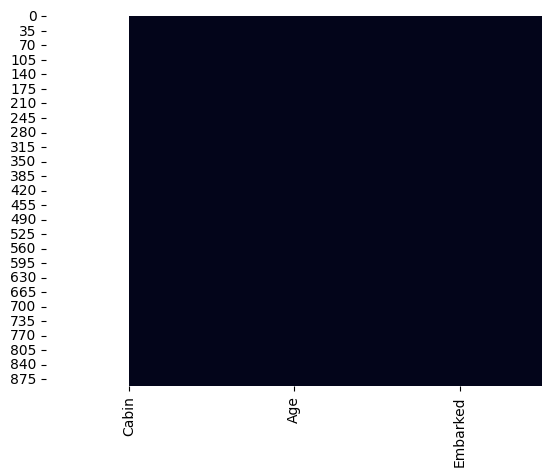

In [ ]:
import seaborn as sns
# Missing Values Heatmap
sns.heatmap(df.isna(), cbar=False)

'''
This immediately shows:

missingness structure
grouped missing values
data pipeline problems
'''


<Axes: >

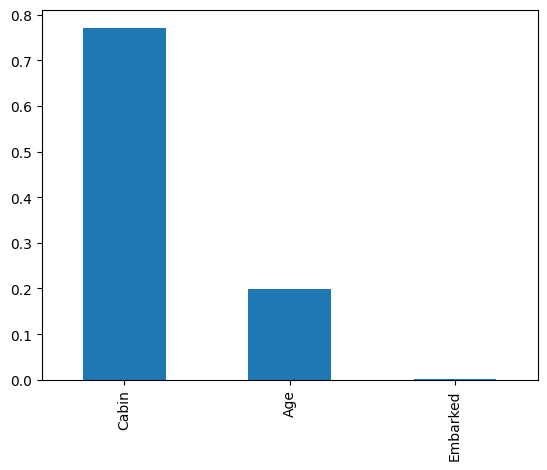

In [ ]:
# Missing Percentage Barplot
missing = df.isna().mean().sort_values(ascending=False)

missing[missing > 0].plot.bar()

<Axes: >

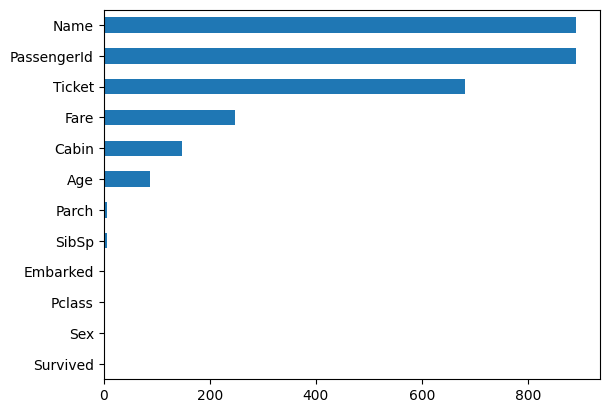

In [38]:
# cardinality barplot
df.nunique().sort_values().plot.barh()